<a href="https://colab.research.google.com/github/Sara-Qassimi/RS_code/blob/colab/Popularity_based_RS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To implement a popularity-based recommender system on the Movielens dataset, follow the steps below:

First, download the Movielens dataset from https://grouplens.org/datasets/movielens/. We will be using the "ml-latest-small.zip" file.

Upload the dataset to Google Colab. You can do this by clicking on the "Files" button on the left-hand side of the screen and selecting "Upload".

Load the dataset into a pandas DataFrame:



In [ ]:
import pandas as pd
from google.colab import drive 
drive.mount('/content/gdrive')

movies_df = pd.read_csv('gdrive/MyDrive/RS/movies.csv')
ratings_df = pd.read_csv('gdrive/MyDrive/RS/ratings.csv')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Calculate the popularity of each movie. We can do this by counting the number of ratings for each movie:

In [ ]:
movie_popularity = ratings_df.groupby('movieId')['rating'].count().sort_values(ascending=False)


Recommend the most popular movies by returning the top N movies from the popularity DataFrame:

In [ ]:
def recommend_popular_movies(N):
    top_movies = movie_popularity.index.values[:N]
    return movies_df[movies_df['movieId'].isin(top_movies)]



Call the recommend_popular_movies function with the number of movies you want to recommend:

In [ ]:
recommend_popular_movies(10)


,movieId,title,genres
97,110,Braveheart (1995),Action|Drama|War
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
277,318,"Shawshank Redemption, The (1994)",Crime|Drama
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
461,527,Schindler's List (1993),Drama|War
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller


 visualize the top 6 movies according to popularity based recommender system.

'recommend_popular_movies_plot'function to sort the movies based on the number of ratings and return the top n movies:

In [ ]:
def recommend_popular_movies_plot(movies_df, ratings_df, top_n=10):
    # Merge the movies and ratings dataframes
    movie_ratings = pd.merge(movies_df, ratings_df.groupby('movieId')['rating'].count(),
                             left_on='movieId', right_index=True)
    
    # Sort the movies based on the number of ratings
    popular_movies = movie_ratings.sort_values('rating', ascending=False)

    # Get the top n movies
    top_movies = popular_movies.head(top_n)

    # Return the top n movies
    return top_movies[['title', 'rating']]


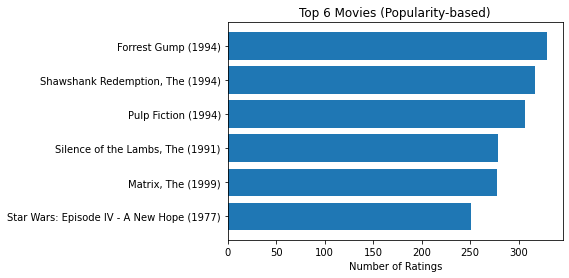

In [ ]:
import matplotlib.pyplot as plt

# Call the recommend_popular_movies function to get the top 6 movies
top_movies = recommend_popular_movies_plot(movies_df, ratings_df, top_n=6)

# Plot a horizontal bar chart
plt.barh(top_movies['title'], top_movies['rating'])
plt.gca().invert_yaxis()
plt.xlabel('Number of Ratings')
plt.title('Top 6 Movies (Popularity-based)')
plt.show()
